========== FIRST 5 ROWS ==========
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

========== DATASET SHAPE ==========
(506, 14)

========== COLUMN NAMES ==========
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

========== MISSING VALUES ==========
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD

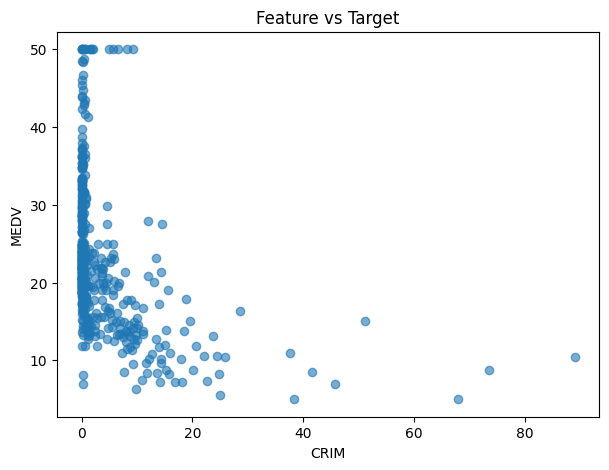

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_excel("boston_housing_clean.xlsx")

print("========== FIRST 5 ROWS ==========")
print(df.head())


# Dataset dimensions

print("\n========== DATASET SHAPE ==========")
print(df.shape)


# Column names

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

# Missing values

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())


# Total missing values

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


# Duplicate rows

print("\n========== DUPLICATE ROWS ==========")
print("Number of duplicate rows:", df.duplicated().sum())


# Descriptive statistics

print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df.describe())

# Filling missing numerical values using median

for column in df.select_dtypes(include=np.number).columns:

    df[column] = df[column].fillna(
        df[column].median()
    )


print("\nMissing values after handling:")
print(df.isnull().sum().sum())

# Target variable

target = "MEDV"


# Independent variables

X = df.drop(target, axis=1)


# Dependent variable

y = df[target]


print("\n========== FEATURES ==========")

print(X.columns.tolist())

print("\nNumber of Features:", X.shape[1])

print("\nTarget Variable:", target)


# Feature vs Target

plt.figure(figsize=(7, 5))

plt.scatter(
    X.iloc[:, 0],
    y,
    alpha=0.6
)

plt.xlabel(X.columns[0])
plt.ylabel("MEDV")
plt.title("Feature vs Target")

plt.show()

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n========== TRAIN TEST SPLIT ==========")

print("Training samples:", X_train.shape[0])

print("Testing samples:", X_test.shape[0])


========== TRAIN TEST SPLIT ==========
Training samples: 404
Testing samples: 102


In [58]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


print("\nFeature scaling completed.")


Feature scaling completed.


In [59]:
linear = LinearRegression()


linear.fit(
    X_train_scaled,
    y_train
)


linear_pred = linear.predict(
    X_test_scaled
)


# Metrics

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_mse = mean_squared_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    linear_mse
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)


print("\n========== LINEAR REGRESSION ==========")

print("MAE:", linear_mae)

print("MSE:", linear_mse)

print("RMSE:", linear_rmse)

print("R2 Score:", linear_r2)


========== LINEAR REGRESSION ==========
MAE: 3.191508972274804
MSE: 24.311426929693326
RMSE: 4.930661915979773
R2 Score: 0.6684825753971608


In [60]:
lasso = Lasso(
    max_iter=50000
)


# Alpha values

alpha_values = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]


parameters = {
    "alpha": alpha_values
}


# Grid Search

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=parameters,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)


lasso_grid.fit(
    X_train_scaled,
    y_train
)


# Best model

lasso = lasso_grid.best_estimator_


# Prediction

lasso_pred = lasso.predict(
    X_test_scaled
)


# Metrics

lasso_mae = mean_absolute_error(
    y_test,
    lasso_pred
)

lasso_mse = mean_squared_error(
    y_test,
    lasso_pred
)

lasso_rmse = np.sqrt(
    lasso_mse
)

lasso_r2 = r2_score(
    y_test,
    lasso_pred
)


print("\n========== LASSO REGRESSION ==========")

print(
    "Best Alpha:",
    lasso_grid.best_params_["alpha"]
)

print("MAE:", lasso_mae)

print("MSE:", lasso_mse)

print("RMSE:", lasso_rmse)

print("R2 Score:", lasso_r2)


========== LASSO REGRESSION ==========
Best Alpha: 0.0001
MAE: 3.1914153366166254
MSE: 24.3117557035168
RMSE: 4.9306952555919334
R2 Score: 0.6684780921452501


In [64]:
ridge = Ridge()


parameters = {
    "alpha": alpha_values
}


ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=parameters,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)


ridge_grid.fit(
    X_train_scaled,
    y_train
)


# Best model

ridge = ridge_grid.best_estimator_


# Prediction

ridge_pred = ridge.predict(
    X_test_scaled
)


# Metrics

ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    ridge_mse
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)


print("\n========== RIDGE REGRESSION ==========")

print(
    "Best Alpha:",
    ridge_grid.best_params_["alpha"]
)

print("MAE:", ridge_mae)

print("MSE:", ridge_mse)

print("RMSE:", ridge_rmse)

print("R2 Score:", ridge_r2)



========== RIDGE REGRESSION ==========
Best Alpha: 1
MAE: 3.188068869676247
MSE: 24.3328746940325
RMSE: 4.9328363741393755
R2 Score: 0.668190107677443


In [65]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Lasso Regression",
        "Ridge Regression"
    ],

    "MAE": [
        linear_mae,
        lasso_mae,
        ridge_mae
    ],

    "MSE": [
        linear_mse,
        lasso_mse,
        ridge_mse
    ],

    "RMSE": [
        linear_rmse,
        lasso_rmse,
        ridge_rmse
    ],

    "R2 Score": [
        linear_r2,
        lasso_r2,
        ridge_r2
    ]

})


print("\n========== MODEL COMPARISON ==========")

print(
    results.round(4)
)


print("\n========== BEST ALPHA VALUES ==========")

print(
    "Best Lasso Alpha:",
    lasso_grid.best_params_["alpha"]
)

print(
    "Best Ridge Alpha:",
    ridge_grid.best_params_["alpha"]
)



========== MODEL COMPARISON ==========
               Model     MAE      MSE    RMSE  R2 Score
0  Linear Regression  3.1915  24.3114  4.9307    0.6685
1   Lasso Regression  3.1914  24.3118  4.9307    0.6685
2   Ridge Regression  3.1881  24.3329  4.9328    0.6682

========== BEST ALPHA VALUES ==========
Best Lasso Alpha: 0.0001
Best Ridge Alpha: 1


In [51]:


coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Linear Regression":
        linear.coef_,

    "Lasso Regression":
        lasso.coef_,

    "Ridge Regression":
        ridge.coef_

})


print("\n========== COEFFICIENT COMPARISON ==========")

print(
    coefficients.round(4)
)


print("\n========== ZERO LASSO COEFFICIENTS ==========")

zero_features = []


for i in range(len(X.columns)):

    if lasso.coef_[i] == 0:

        zero_features.append(
            X.columns[i]
        )


if len(zero_features) == 0:

    print(
        "No coefficients became zero."
    )

else:

    for feature in zero_features:

        print(
            feature
        )


========== COEFFICIENT COMPARISON ==========
    Feature  Linear Regression  Lasso Regression  Ridge Regression
0      CRIM            -0.9962           -0.9960           -0.9863
1        ZN             0.6956            0.6951            0.6771
2     INDUS             0.2805            0.2796            0.2546
3      CHAS             0.7193            0.7194            0.7231
4       NOX            -2.0268           -2.0262           -1.9952
5        RM             3.1407            3.1408            3.1472
6       AGE            -0.1745           -0.1742           -0.1757
7       DIS            -3.0832           -3.0825           -3.0463
8       RAD             2.2487            2.2469            2.1706
9       TAX            -1.7657           -1.7639           -1.6944
10  PTRATIO            -2.0398           -2.0397           -2.0299
11        B             1.1387            1.1386            1.1363
12    LSTAT            -3.6172           -3.6172           -3.6044

========== ZERO

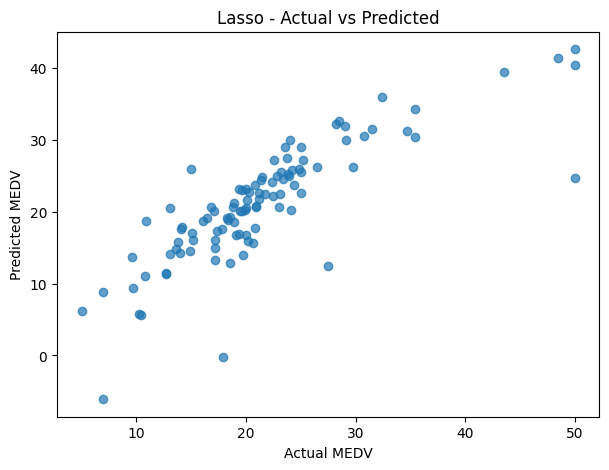

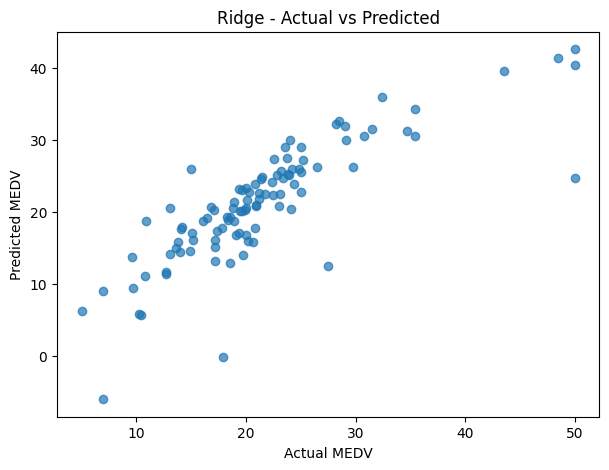

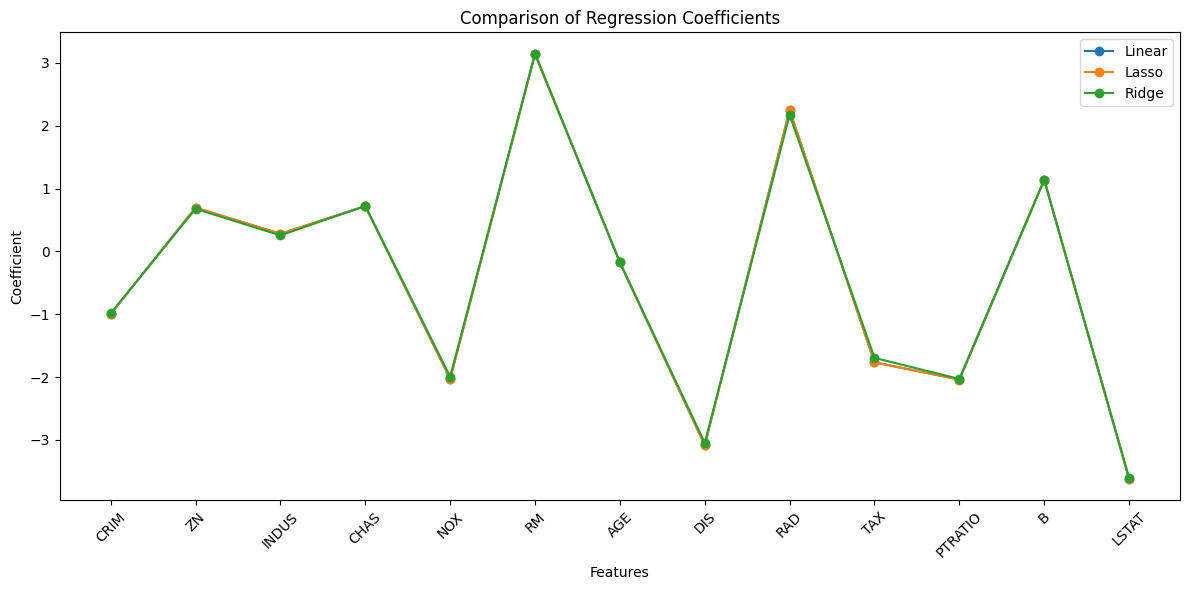

In [52]:


plt.figure(figsize=(7, 5))


plt.scatter(
    y_test,
    lasso_pred,
    alpha=0.7
)


plt.xlabel("Actual MEDV")

plt.ylabel("Predicted MEDV")

plt.title(
    "Lasso - Actual vs Predicted"
)


plt.show()



# ACTUAL VS PREDICTED - RIDGE


plt.figure(figsize=(7, 5))


plt.scatter(
    y_test,
    ridge_pred,
    alpha=0.7
)


plt.xlabel("Actual MEDV")

plt.ylabel("Predicted MEDV")

plt.title(
    "Ridge - Actual vs Predicted"
)


plt.show()


#COEFFICIENT VISUALIZATION


plt.figure(figsize=(12, 6))


plt.plot(
    X.columns,
    linear.coef_,
    marker="o",
    label="Linear"
)


plt.plot(
    X.columns,
    lasso.coef_,
    marker="o",
    label="Lasso"
)


plt.plot(
    X.columns,
    ridge.coef_,
    marker="o",
    label="Ridge"
)


plt.xlabel("Features")

plt.ylabel("Coefficient")

plt.title(
    "Comparison of Regression Coefficients"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.show()

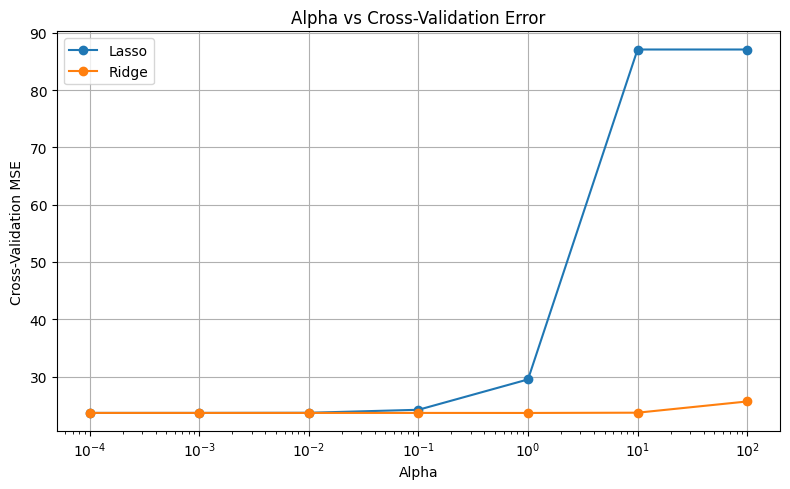

In [66]:

# CROSS-VALIDATION PERFORMANCE VS ALPHA

lasso_cv = pd.DataFrame(
    lasso_grid.cv_results_
)

ridge_cv = pd.DataFrame(
    ridge_grid.cv_results_
)


# Convert negative MSE to positive MSE

lasso_error = -lasso_cv[
    "mean_test_score"
]

ridge_error = -ridge_cv[
    "mean_test_score"
]


alphas = lasso_cv[
    "param_alpha"
].astype(float)


plt.figure(figsize=(8, 5))


plt.plot(
    alphas,
    lasso_error,
    marker="o",
    label="Lasso"
)


plt.plot(
    alphas,
    ridge_error,
    marker="o",
    label="Ridge"
)


plt.xscale("log")


plt.xlabel("Alpha")

plt.ylabel(
    "Cross-Validation MSE"
)

plt.title(
    "Alpha vs Cross-Validation Error"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


In [54]:

# SELF-LEARNING IMPROVEMENT
# POLYNOMIAL RIDGE REGRESSION


print("\n==========================================")
print("SELF-LEARNING: POLYNOMIAL RIDGE")
print("==========================================")


# Create polynomial features

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)


X_train_poly = poly.fit_transform(
    X_train
)


X_test_poly = poly.transform(
    X_test
)


print(
    "\nOriginal number of features:",
    X_train.shape[1]
)

print(
    "New number of features:",
    X_train_poly.shape[1]
)


# Scale polynomial features

poly_scaler = StandardScaler()


X_train_poly = poly_scaler.fit_transform(
    X_train_poly
)


X_test_poly = poly_scaler.transform(
    X_test_poly
)


# Ridge model

poly_ridge = Ridge()


poly_parameters = {

    "alpha": [
        0.01,
        0.1,
        1,
        10,
        100
    ]

}


# GridSearchCV

poly_grid = GridSearchCV(

    estimator=poly_ridge,

    param_grid=poly_parameters,

    cv=5,

    scoring="r2",

    n_jobs=-1
)


poly_grid.fit(
    X_train_poly,
    y_train
)


# Best model

best_poly_ridge = (
    poly_grid.best_estimator_
)


# Prediction

poly_pred = best_poly_ridge.predict(
    X_test_poly
)


# Metrics

poly_mae = mean_absolute_error(
    y_test,
    poly_pred
)


poly_mse = mean_squared_error(
    y_test,
    poly_pred
)


poly_rmse = np.sqrt(
    poly_mse
)


poly_r2 = r2_score(
    y_test,
    poly_pred
)


print(
    "\nBest Polynomial Ridge Alpha:",
    poly_grid.best_params_["alpha"]
)


print(
    "MAE:",
    poly_mae
)


print(
    "MSE:",
    poly_mse
)


print(
    "RMSE:",
    poly_rmse
)


print(
    "R2 Score:",
    poly_r2
)



# ORIGINAL RIDGE VS IMPROVED RIDGE


improvement = pd.DataFrame({

    "Model": [

        "Original Ridge",

        "Polynomial Ridge"

    ],

    "RMSE": [

        ridge_rmse,

        poly_rmse

    ],

    "R2 Score": [

        ridge_r2,

        poly_r2

    ]

})


print("\n========== IMPROVEMENT COMPARISON ==========")

print(
    improvement.round(4)
)



# CHECK IMPROVEMENT


print("\n========== PERFORMANCE CHECK ==========")


if poly_r2 > ridge_r2:

    print(
        "Polynomial Ridge improved the R2 Score."
    )

else:

    print(
        "Polynomial Ridge did not improve the R2 Score."
    )


if poly_rmse < ridge_rmse:

    print(
        "Polynomial Ridge reduced the RMSE."
    )

else:

    print(
        "Polynomial Ridge did not reduce the RMSE."
    )




SELF-LEARNING: POLYNOMIAL RIDGE

Original number of features: 13
New number of features: 104

Best Polynomial Ridge Alpha: 1
MAE: 2.207972022461996
MSE: 11.192908555444546
RMSE: 3.3455804511989466
R2 Score: 0.8473703650202457

========== IMPROVEMENT COMPARISON ==========
              Model    RMSE  R2 Score
0    Original Ridge  4.9328    0.6682
1  Polynomial Ridge  3.3456    0.8474

========== PERFORMANCE CHECK ==========
Polynomial Ridge improved the R2 Score.
Polynomial Ridge reduced the RMSE.


In [55]:


print("\n==========================================")
print("FINAL RESULTS")
print("==========================================")


print(
    results.round(4)
)


print("\nBest Lasso Alpha:",
      lasso_grid.best_params_["alpha"])


print("Best Ridge Alpha:",
      ridge_grid.best_params_["alpha"])


print(
    "\nImproved Polynomial Ridge R2:",
    round(poly_r2, 4)
)


print(
    "Improved Polynomial Ridge RMSE:",
    round(poly_rmse, 4)
)


FINAL RESULTS
               Model     MAE      MSE    RMSE  R2 Score
0  Linear Regression  3.1915  24.3114  4.9307    0.6685
1   Lasso Regression  3.1914  24.3118  4.9307    0.6685
2   Ridge Regression  3.1881  24.3329  4.9328    0.6682

Best Lasso Alpha: 0.0001
Best Ridge Alpha: 1

Improved Polynomial Ridge R2: 0.8474
Improved Polynomial Ridge RMSE: 3.3456



    "Alpha controls the strength of regularization."




   "A higher alpha applies stronger regularization."




    "Lasso can make some coefficients exactly zero."




    " Ridge reduces the size of coefficients."




    " Feature scaling is important because "
    "Lasso and Ridge apply penalties to coefficients."




    "Polynomial features help the model capture "
    "nonlinear relationships."



    "GridSearchCV helps select a suitable alpha "
    "using 5-fold cross-validation."

